### 전이학습
- 전이학습이란 사전학습된 모델의 지식을 새로운 다른 데이터에 적용하는 방법
  - 모델이 이미 학습한 일반적인 직식을 기반으로 더욱 빠르고 효과적인 학습이 가능
  - 적은 양의 데이터로 새로운 데이터에 대한 학습을 가속화 하며 성능을 향상시키는데 유용
  - 자연어처리, 컴퓨터 비전 등 다양한 분야에서 사용되고 있다.
  - 사전 학습된 모델의 일부 또는 전체를 사용하는 방법

### 전이학습의 종류
- 특성추출방식
  - CNN층에서 특성추출부만을 가져와서 사용하는 방식으로 MLP층만 내 데이터에 맞도록 다시 설계하여 사용하는 방법으로 CNN층은 그대로 사용
  - 사전학습된 데이터와 사용할 데이터의 특성이 너무나 다를 경우에는 성능이 안나올 수 있음
- 미세조정방식
  - 기존에 학습된 모델을 기반으로 새로운 목적에 맞게 변형하고 이미 학습된 모델의 '가중치'를 미세하게 조정시키는 방식으로 CNN층의 일부분을 나의 데이터에 맞도록 변형시켜서 사용하는 방법

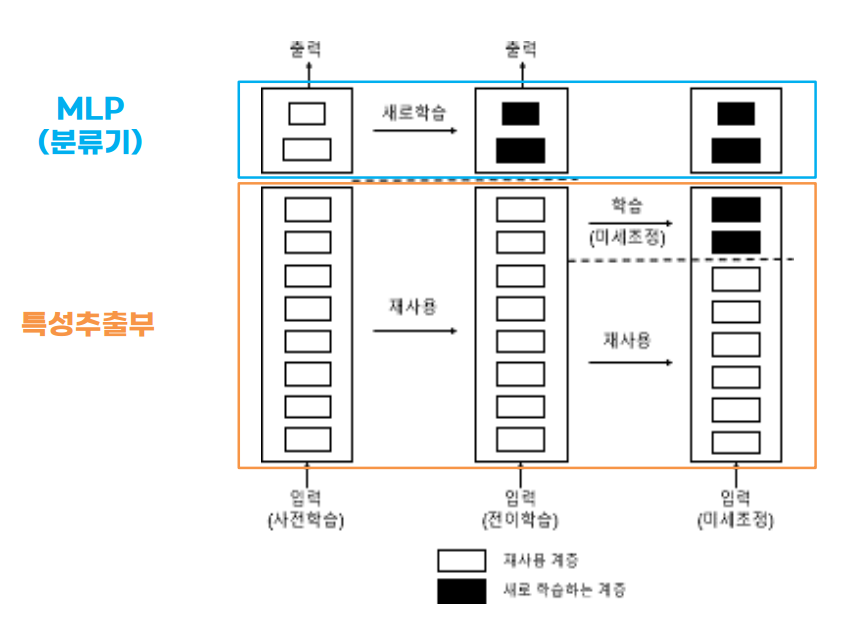

In [1]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 작업 디렉토리(작업공간) 변경
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝(인공지능사관학교)

/content/drive/MyDrive/Colab Notebooks/딥러닝(인공지능사관학교)


### 데이터 불러오기
- 우리가 압축을 풀어서 사용했던 동물 데이터 그대로 사용

In [3]:
# 도구 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.utils import image_dataset_from_directory
from tqdm import tqdm

In [4]:
# 데이터 불러오기
train_data = image_dataset_from_directory(
    directory = './data/animal/animal_small',
    labels = 'inferred',
    label_mode = 'categorical',
    color_mode = 'rgb',
    image_size = (224,224)
)

Found 2000 files belonging to 4 classes.


In [5]:
# 데이터를 사용할 수 있는 형태로 변경
X_train = []
y_train = []

for img, label in tqdm(train_data.as_numpy_iterator()):
  X_train.append(img)
  y_train.append(label)

# 배열을 연결
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

63it [05:59,  5.71s/it]


In [6]:
# 데이터 크기확인
print(X_train.shape)
print(y_train.shape)

(2000, 224, 224, 3)
(2000, 4)


### VGG16
- CNN 아키텍처로 획기적인 객체 인식 모델을 기초로 ImageNet에서 높은 정확도를 보이는 모델

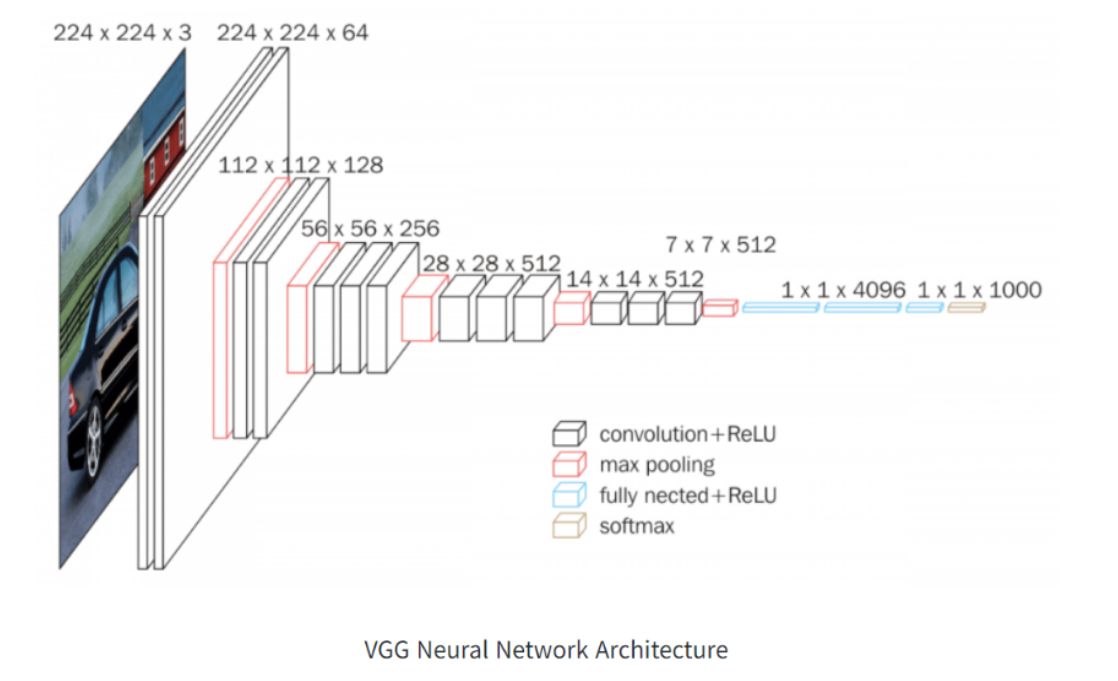

### VGG16 구조
- 13개의 Convolution Layer로 구성된 CNN아키텍처 모델
- 모든 Convolution Layer의 커널의 크기는 (3,3)으로 이루어저 있고 함수는 Relu를 사용
- 입력 이미지의 크기는 (224,224,3)의 컬러 이미지를 사용

In [7]:
# VGG16모델 로드
from tensorflow.keras.applications import VGG16

In [8]:
# 모델 가져오기
vgg16 = VGG16(
    include_top = False, # MLP층을 사용하지 않도록 설정
    weights = 'imagenet', # imagenet으로 학습된 정보를 사용(가중치 값)
    input_shape = (224,224,3) # 입력할 데이터의 크기 (입력층)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
# 특성추출방식을 사용하기 위해 CNN부분은 그대로 유지하도록 동결 설정하기
# 동결 : 기존에 학습된 정보를 변경시키지 않고 그대로 사용하도록
# 내 데이터가 추가 학습이 되지 않게 설정하는 방법

# 동결설정
vgg16.trainable = False # 학습을 할지 안할지의 유무를 설정
# trainable = False -> 동결설정(추가로 학습을 하지 않도록 설정)

In [10]:
# 전이학습을 위해 인공신경망 설계
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer, Flatten

In [11]:
# 특성추출방식 모델 설계

# 뼈대생성
transfor_model = Sequential()

# vgg16 모델을 내 모델에 추가
transfor_model.add(vgg16)

# ---------분류기(MLP층) 설정-------------------
# 3차원의 데이터를 1차원으로 펴주기
transfor_model.add(Flatten())

# 중간층 쌓기
transfor_model.add(Dense(units = 64, activation = 'relu'))
transfor_model.add(Dense(units = 128, activation = 'relu'))
transfor_model.add(Dense(units = 64, activation = 'relu'))

# 출력층 쌓기
transfor_model.add(Dense(units = 4, activation = 'softmax'))

In [12]:
# 학습방법 및 평가방법 설정
transfor_model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [13]:
# 학습진행
transfor_model.fit(
    X_train, y_train, validation_split = 0.2, epochs = 20
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 484ms/step - accuracy: 0.7337 - loss: 2.3108 - val_accuracy: 0.8225 - val_loss: 1.0466
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 237ms/step - accuracy: 0.9256 - loss: 0.5588 - val_accuracy: 0.8825 - val_loss: 0.9618
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - accuracy: 0.9675 - loss: 0.1830 - val_accuracy: 0.8725 - val_loss: 1.1362
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - accuracy: 0.9812 - loss: 0.0879 - val_accuracy: 0.8750 - val_loss: 1.2810
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 231ms/step - accuracy: 0.9906 - loss: 0.0360 - val_accuracy: 0.9175 - val_loss: 1.0357
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.9912 - loss: 0.0407 - val_accuracy: 0.8850 - val_loss: 1.4435
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 240ms/step - accuracy: 0.9806 - loss: 0.1816 - val_accuracy: 0.8850 - val_loss: 1.8485
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - accuracy: 0.9731 - loss: 0.2510 - val_accu

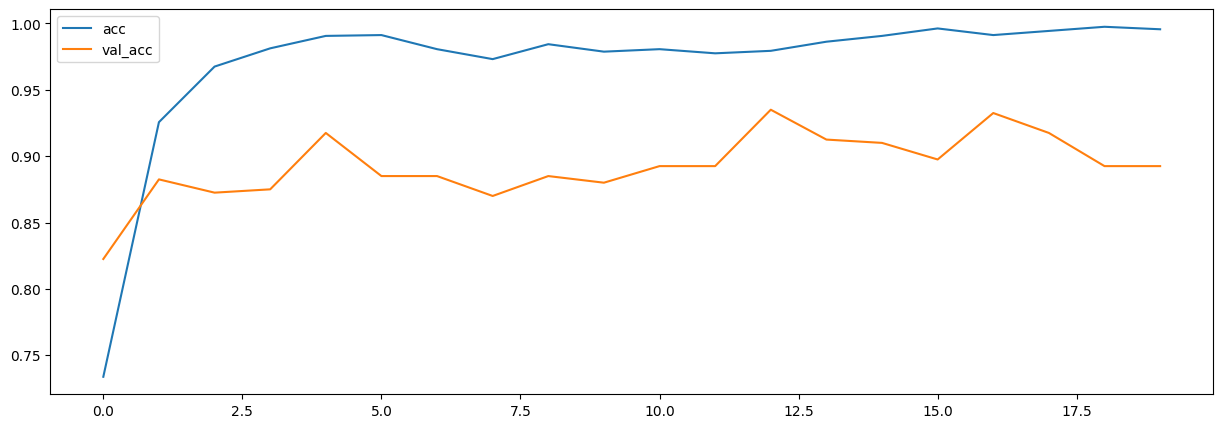

In [14]:
# 시각화
plt.figure(figsize=(15,5))
plt.plot(transfor_model.history.history['accuracy'], label='acc')
plt.plot(transfor_model.history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### 미세조정 방식 사용
- CNN층의 하단의 일부분 층을 내 데이터로 학습시켜 사용하는 방법

In [15]:
# 모델 정보 확인
# model.summary()
vgg16.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### 정보확인
- 하단의 block5_conv3 층을 활용하여 미세조정 진행

In [17]:
for layer in vgg16.layers:
  print(layer.name)

input_layer
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3
block4_pool
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [20]:
# 마지막층인 block5_cov3층을 학습을 시키고 그 외에 모든층은 동결 설정

# 새로운 모델 설계 진행
transfor_model2 = Sequential()

# vgg16을 추가하기 전에 학습이 진행될 block5_cov3는 학습이 진행되고
# 나머지 층은 동결을 하도록 설정을 진행

# 미세조정 설정 -------------------------------------
for layer in vgg16.layers:
  if layer.name == 'block5_conv3':
    layer.trainable = True # 학습이 가능하도록 설정
  else :
    layer.trainalbe = False # 동결 설정
# -----------------------------------------------------
# 설정한 vgg16모델 추가
transfor_model2.add(vgg16)

# Flatten층 쌓기 (1차원으로 변경)
transfor_model2.add(Flatten())

# MLP층 쌓기 ---------------------------
transfor_model2.add(Dense(units = 64, activation = 'relu'))
transfor_model2.add(Dense(units = 128, activation = 'relu'))
transfor_model2.add(Dense(units = 64, activation = 'relu'))

# 출력층
transfor_model2.add(Dense(units = 4, activation = 'softmax'))